# surrogate CNN + RetroFL + cached anchor targets

这个版本做了两件事：

1. 把 BigTable 里的 RetroFL 训练逻辑接到 surrogate CNN 上。  
2. 不再在每个 batch 里重复执行 `self.anchor_model(matrices, other_freq_idx)`；而是在每次 `anchor_model` 更新时，直接对本地数据集预计算并缓存 `y_anchor`，后续 batch 直接查缓存。

In [1]:
import math
import random
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [2]:
# ============================================================
# basic config
# ============================================================
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

TARGET_MODE = "sparam"

MATRIX_DIR = Path("./Auged_diag_dataset_pack_full")
TARGET_DIR = Path("./Auged_diag_dataset_pack_120")
SAVE_DIR = Path("./retrofl_surrogate_outputs")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 512
LEARNING_RATE = 3.5e-4
TOTAL_ROUNDS = 128
TEST_RATIO = 0.05
OVERLAP_RATIO = 0.25

ONLINE_SPAN_RANGE = (3, 8)
OFFLINE_SPAN_RANGE = (5, 20)
INIT_ONLINE_PROB = 0.5
MIN_ONLINE_CLIENTS = 1

print("DEVICE:", DEVICE)

DEVICE: cuda


In [3]:
# ============================================================
# dataset utils
# ============================================================
def load_rf_pack(matrix_dir: Path, target_dir: Path, target_mode: str):
    matrix = np.load(matrix_dir / "matrix.npy")   # [N,1,H,W]
    freq = np.load(target_dir / "freq.npy")       # [Nf]

    if target_mode == "sparam":
        target = np.load(target_dir / "sparam.npy")   # [N,4,Nf]
    elif target_mode == "mag":
        target = np.load(target_dir / "mag.npy")      # [N,2,Nf]
    elif target_mode == "db":
        target = np.load(target_dir / "db.npy")       # [N,2,Nf]
    else:
        raise ValueError(f"Unknown TARGET_MODE: {target_mode}")

    if len(matrix) != len(target):
        raise ValueError(f"matrix samples {len(matrix)} != target samples {len(target)}")

    return {
        "matrix": matrix.astype(np.float32),
        "freq": freq.astype(np.float32),
        "target": target.astype(np.float32),
        "n_samples": len(matrix),
        "n_freq": target.shape[-1],
    }


def build_frequency_groups(n_freq: int, n_groups: int = 5) -> List[np.ndarray]:
    return [np.arange(i, n_freq, n_groups, dtype=np.int64) for i in range(n_groups)]


def build_overlapping_circuit_groups(circuit_indices: np.ndarray, n_groups: int = 4, overlap_ratio: float = 0.25):
    circuit_indices = np.asarray(circuit_indices, dtype=np.int64)
    n = len(circuit_indices)
    if n_groups == 1:
        return [circuit_indices.copy()]

    window = int(math.ceil(n / n_groups))
    overlap = int(round(window * overlap_ratio))
    step = max(1, window - overlap)

    groups = []
    start = 0
    for _ in range(n_groups):
        end = min(start + window, n)
        part = circuit_indices[start:end]
        if len(part) == 0:
            part = circuit_indices[max(0, n - window):n]
        groups.append(np.asarray(part, dtype=np.int64))
        start += step
        if start >= n:
            start = max(0, n - window)

    return groups


class ClientFreqDataset(Dataset):
    def __init__(self, matrix: np.ndarray, target: np.ndarray, circuit_indices: np.ndarray, freq_indices: np.ndarray):
        self.matrix = matrix
        self.target = target
        self.circuit_indices = np.asarray(circuit_indices, dtype=np.int64)
        self.freq_indices = np.asarray(freq_indices, dtype=np.int64)

    def __len__(self):
        return len(self.circuit_indices)

    def __getitem__(self, idx):
        ci = int(self.circuit_indices[idx])
        x = self.matrix[ci]
        y = self.target[ci][:, self.freq_indices]
        return {
            "matrix": torch.as_tensor(x, dtype=torch.float32),
            "freq_index": torch.as_tensor(self.freq_indices, dtype=torch.long),
            "target": torch.as_tensor(y, dtype=torch.float32),
            "sample_index": ci,
        }


class FullFreqDataset(Dataset):
    def __init__(self, matrix: np.ndarray, target: np.ndarray, circuit_indices: np.ndarray):
        self.matrix = matrix
        self.target = target
        self.circuit_indices = np.asarray(circuit_indices, dtype=np.int64)
        self.freq_indices = np.arange(target.shape[-1], dtype=np.int64)

    def __len__(self):
        return len(self.circuit_indices)

    def __getitem__(self, idx):
        ci = int(self.circuit_indices[idx])
        x = self.matrix[ci]
        y = self.target[ci]
        return {
            "matrix": torch.as_tensor(x, dtype=torch.float32),
            "freq_index": torch.as_tensor(self.freq_indices, dtype=torch.long),
            "target": torch.as_tensor(y, dtype=torch.float32),
            "sample_index": ci,
        }


def make_client_specs(train_indices: np.ndarray, n_clients: int, n_freq: int, overlap_ratio: float = 0.25):
    freq_groups = build_frequency_groups(n_freq=n_freq, n_groups=5)
    circuit_groups = build_overlapping_circuit_groups(train_indices, n_groups=4, overlap_ratio=overlap_ratio)

    specs = []
    if n_clients == 3:
        circ = circuit_groups[0]
        for i in range(3):
            specs.append({
                "client_id": f"C{i}",
                "circuit_group_id": 0,
                "freq_group_id": i,
                "circuit_indices": circ,
                "freq_indices": freq_groups[i],
            })
    elif n_clients == 5:
        circ = circuit_groups[0]
        for i in range(5):
            specs.append({
                "client_id": f"C{i}",
                "circuit_group_id": 0,
                "freq_group_id": i,
                "circuit_indices": circ,
                "freq_indices": freq_groups[i],
            })
    elif n_clients == 10:
        for cg in range(2):
            for fg in range(5):
                specs.append({
                    "client_id": f"G{cg}F{fg}",
                    "circuit_group_id": cg,
                    "freq_group_id": fg,
                    "circuit_indices": circuit_groups[cg],
                    "freq_indices": freq_groups[fg],
                })
    elif n_clients == 20:
        for cg in range(4):
            for fg in range(5):
                specs.append({
                    "client_id": f"G{cg}F{fg}",
                    "circuit_group_id": cg,
                    "freq_group_id": fg,
                    "circuit_indices": circuit_groups[cg],
                    "freq_indices": freq_groups[fg],
                })
    else:
        raise ValueError("n_clients must be one of {3,5,10,20}")

    return specs

In [4]:
# ============================================================
# surrogate CNN model (from surrogate_CNN.ipynb)
# ============================================================
class FrequencyEmbedding(nn.Module):
    def __init__(self, num_freqs=120, embed_dim=64):
        super().__init__()
        self.embed = nn.Embedding(num_freqs, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, embed_dim),
        )

    def forward(self, freq_idx):
        x = self.embed(freq_idx)
        x = self.norm(x)
        x = self.mlp(x)
        return x


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.GroupNorm(num_groups=8, num_channels=out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.GroupNorm(num_groups=8, num_channels=out_channels)

        if in_channels != out_channels or stride != 1:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.GroupNorm(num_groups=8, num_channels=out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity
        out = self.relu(out)
        return out


class ResNetFeatureExtractor(nn.Module):
    def __init__(self, base_channels=64, out_dim=256):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, base_channels, 3, 1, 1, bias=False),
            nn.GroupNorm(num_groups=8, num_channels=base_channels),
            nn.ReLU(inplace=True),
        )
        self.layer1 = nn.Sequential(
            ResidualBlock(base_channels, base_channels),
            ResidualBlock(base_channels, base_channels),
            ResidualBlock(base_channels, base_channels),
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(base_channels, base_channels * 2, stride=2),
            ResidualBlock(base_channels * 2, base_channels * 2),
            ResidualBlock(base_channels * 2, base_channels * 2),
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(base_channels * 2, out_dim, stride=2),
            ResidualBlock(out_dim, out_dim),
            ResidualBlock(out_dim, out_dim),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)
        x = x.flatten(1)
        return x


class ResNetFreqSurrogate(nn.Module):
    def __init__(
        self,
        freq_dim=64,
        structure_dim=256,
        hidden_dim=512,
        dropout=0.3,
        num_freqs=120,
    ):
        super().__init__()
        self.feature_extractor = ResNetFeatureExtractor(
            base_channels=64,
            out_dim=structure_dim,
        )
        self.freq_embed = FrequencyEmbedding(num_freqs=num_freqs, embed_dim=freq_dim)
        self.head = nn.Sequential(
            nn.Linear(structure_dim + freq_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 4),
        )
        self.out_act = nn.Tanh()

    def forward(self, matrix, freq):
        struct_feat = self.feature_extractor(matrix)
        freq_feat = self.freq_embed(freq)

        B, Nf, Df = freq_feat.shape
        Ds = struct_feat.shape[1]

        struct_feat = struct_feat.unsqueeze(1).expand(B, Nf, Ds)
        fusion = torch.cat([struct_feat, freq_feat], dim=-1)

        out = self.head(fusion)
        out = self.out_act(out)
        return out.transpose(1, 2)


def build_model(num_freqs: int):
    return ResNetFreqSurrogate(
        freq_dim=64,
        structure_dim=256,
        hidden_dim=512,
        dropout=0.3,
        num_freqs=num_freqs,
    ).to(DEVICE)

In [5]:
# ============================================================
# metrics / utilities
# ============================================================
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def compute_r2(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    ss_res = 0.0
    y_sum = 0.0
    y_sq_sum = 0.0
    n_elem = 0

    for batch in loader:
        matrices = batch["matrix"].to(DEVICE, non_blocking=True)
        freq_indices = batch["freq_index"].to(DEVICE, dtype=torch.long, non_blocking=True)
        targets = batch["target"].to(DEVICE, non_blocking=True)

        pred = model(matrices, freq_indices)
        diff = pred - targets
        ss_res += float((diff * diff).sum().item())
        y_sum += float(targets.sum().item())
        y_sq_sum += float((targets * targets).sum().item())
        n_elem += int(targets.numel())

    if n_elem == 0:
        return float("nan")
    y_mean = y_sum / n_elem
    ss_tot = y_sq_sum - n_elem * (y_mean ** 2)
    if abs(ss_tot) < 1e-12:
        return float("nan")
    return 1.0 - ss_res / ss_tot


def compute_train_r2_on_loader(model: nn.Module, loader: DataLoader) -> float:
    return compute_r2(model, loader)

In [6]:
# ============================================================
# online / offline scheduler
# ============================================================
@dataclass
class ClientScheduleState:
    is_online: bool
    remaining_rounds: int


class OnlineOfflineScheduler:
    def __init__(
        self,
        num_clients,
        online_span_range=(3, 8),
        offline_span_range=(5, 20),
        init_online_prob=0.5,
        min_online_clients=1,
        seed=42,
    ):
        self.num_clients = num_clients
        self.online_span_range = online_span_range
        self.offline_span_range = offline_span_range
        self.min_online_clients = min_online_clients
        self.rng = random.Random(seed)

        self.states = []
        for _ in range(num_clients):
            is_online = self.rng.random() < init_online_prob
            span = self._sample_online_span() if is_online else self._sample_offline_span()
            self.states.append(ClientScheduleState(is_online=is_online, remaining_rounds=span))

    def _sample_online_span(self):
        return self.rng.randint(self.online_span_range[0], self.online_span_range[1])

    def _sample_offline_span(self):
        return self.rng.randint(self.offline_span_range[0], self.offline_span_range[1])

    def _flip_state(self, idx):
        st = self.states[idx]
        if st.is_online:
            st.is_online = False
            st.remaining_rounds = self._sample_offline_span()
        else:
            st.is_online = True
            st.remaining_rounds = self._sample_online_span()

    def get_online_clients(self):
        online = [i for i, st in enumerate(self.states) if st.is_online]

        if len(online) < self.min_online_clients:
            offline_ids = [i for i, st in enumerate(self.states) if not st.is_online]
            self.rng.shuffle(offline_ids)
            need = self.min_online_clients - len(online)
            for idx in offline_ids[:need]:
                self.states[idx].is_online = True
                self.states[idx].remaining_rounds = self._sample_online_span()
            online = [i for i, st in enumerate(self.states) if st.is_online]

        return online

    def step(self):
        for idx, st in enumerate(self.states):
            st.remaining_rounds -= 1
            if st.remaining_rounds <= 0:
                self._flip_state(idx)

In [7]:
# ============================================================
# RetroFL with cached anchor targets
# ============================================================
class ParaServer:
    def __init__(self, model: nn.Module, learning_rate: float):
        self.model = model.to(DEVICE)
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=learning_rate, weight_decay=1e-4)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer,
            T_max=TOTAL_ROUNDS,
            eta_min=1e-6,
        )
        self.client_scores: Dict[str, float] = {}

    def upload(self, grads: List[torch.Tensor], client_id: str, score: float):
        self.client_scores[client_id] = max(0.0, float(score))
        self.optimizer.zero_grad(set_to_none=True)
        for p, g in zip(self.model.parameters(), grads):
            p.grad = g.detach()
        self.optimizer.step()
        return self.download()

    def download(self):
        return self.model.state_dict()


class RetroClient:
    def __init__(
        self,
        client_id: str,
        train_loader: DataLoader,
        all_freq_groups: List[np.ndarray],
        my_freq_group_id: int,
        client_to_freq_group: Dict[str, int],
    ):
        self.client_id = client_id
        self.train_loader = train_loader
        self.all_freq_groups = [np.asarray(g, dtype=np.int64) for g in all_freq_groups]
        self.my_freq_group_id = int(my_freq_group_id)
        self.client_to_freq_group = dict(client_to_freq_group)

        self.anchor_model = None
        self.other_scores: Dict[str, float] = {}
        self.anchor_cache: Dict[int, Dict[int, torch.Tensor]] = {}

    def _refresh_anchor_cache(self):
        if self.anchor_model is None:
            self.anchor_cache = {}
            return

        active_fgs = sorted({
            int(self.client_to_freq_group[other_client_id])
            for other_client_id, weight in self.other_scores.items()
            if other_client_id != self.client_id and abs(float(weight)) >= 1e-12
        })

        if len(active_fgs) == 0:
            self.anchor_cache = {}
            return

        cache: Dict[int, Dict[int, torch.Tensor]] = {fg: {} for fg in active_fgs}
        self.anchor_model.eval()

        with torch.no_grad():
            for batch in self.train_loader:
                matrices = batch["matrix"].to(DEVICE, non_blocking=True)
                sample_indices = batch["sample_index"]

                for fg in active_fgs:
                    other_freq_idx = torch.as_tensor(
                        self.all_freq_groups[fg],
                        dtype=torch.long,
                        device=DEVICE,
                    ).unsqueeze(0).expand(matrices.shape[0], -1)

                    y_anchor = self.anchor_model(matrices, other_freq_idx).detach().cpu()

                    for i, sample_idx in enumerate(sample_indices):
                        cache[fg][int(sample_idx)] = y_anchor[i].clone()

        self.anchor_cache = cache

    def _get_cached_anchor_batch(self, fg: int, sample_indices: torch.Tensor):
        if fg not in self.anchor_cache:
            raise KeyError(f"freq_group {fg} not found in anchor_cache")

        cached = [self.anchor_cache[fg][int(si)] for si in sample_indices.tolist()]
        y_anchor = torch.stack(cached, dim=0)
        return y_anchor.to(DEVICE, non_blocking=True)

    def train_one_round(self, ps: ParaServer, model_builder, global_round: int, first_epoch: bool = False):
        if first_epoch:
            self.anchor_model = model_builder().to(DEVICE)
            self.anchor_model.load_state_dict(ps.download())
            self.anchor_model.eval()

            self.other_scores = dict(ps.client_scores)
            self._refresh_anchor_cache()

        model = model_builder().to(DEVICE)
        model.load_state_dict(ps.download())
        model.train()

        for batch in self.train_loader:
            matrices = batch["matrix"].to(DEVICE, non_blocking=True)
            freq_indices = batch["freq_index"].to(DEVICE, dtype=torch.long, non_blocking=True)
            targets = batch["target"].to(DEVICE, non_blocking=True)
            sample_indices = batch["sample_index"]

            model.zero_grad(set_to_none=True)
            pred = model(matrices, freq_indices)
            tr_mse = F.mse_loss(pred, targets)
            tr_mse.backward()
            grads = [p.grad.detach().clone() for p in model.parameters()]

            ss_res = torch.sum((pred - targets) ** 2)
            y_mean = torch.mean(targets)
            ss_tot = torch.sum((targets - y_mean) ** 2)
            if torch.abs(ss_tot) < 1e-12:
                tr_r2 = torch.tensor(0.0, device=DEVICE)
            else:
                tr_r2 = 1 - ss_res / ss_tot

            sum_r2 = 1.0
            if self.anchor_model is not None and len(self.anchor_cache) > 0:
                for other_client_id, weight in self.other_scores.items():
                    weight = float(weight)
                    if other_client_id == self.client_id or abs(weight) < 1e-12:
                        continue

                    fg = int(self.client_to_freq_group[other_client_id])
                    y_anchor = self._get_cached_anchor_batch(fg, sample_indices)

                    other_freq_idx = torch.as_tensor(
                        self.all_freq_groups[fg],
                        dtype=torch.long,
                        device=DEVICE,
                    ).unsqueeze(0).expand(matrices.shape[0], -1)

                    model.zero_grad(set_to_none=True)
                    y_pred_other = model(matrices, other_freq_idx)
                    loss_other = F.mse_loss(y_pred_other, y_anchor)
                    loss_other.backward()
                    grad_other = [p.grad.detach().clone() for p in model.parameters()]

                    grads = [g + go * weight for g, go in zip(grads, grad_other)]
                    sum_r2 += weight

            avg_grads = [g / sum_r2 for g in grads]
            model.load_state_dict(ps.upload(avg_grads, self.client_id, float(tr_r2.detach().item())))

        train_r2 = compute_train_r2_on_loader(model, self.train_loader)
        return train_r2

In [8]:
# ============================================================
# experiment runner
# ============================================================
def build_dataloaders_for_experiment(pack, n_clients: int):
    n_total = pack["n_samples"]
    all_indices = np.arange(n_total, dtype=np.int64)
    train_indices, test_indices = train_test_split(
        all_indices,
        test_size=TEST_RATIO,
        random_state=RANDOM_SEED,
        shuffle=True,
    )

    client_specs = make_client_specs(
        train_indices,
        n_clients=n_clients,
        n_freq=pack["n_freq"],
        overlap_ratio=OVERLAP_RATIO,
    )
    freq_groups = build_frequency_groups(pack["n_freq"], n_groups=5)

    client_loaders = []
    for spec in client_specs:
        ds = ClientFreqDataset(
            matrix=pack["matrix"],
            target=pack["target"],
            circuit_indices=spec["circuit_indices"],
            freq_indices=spec["freq_indices"],
        )
        loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=False)
        client_loaders.append((spec, loader))

    test_ds = FullFreqDataset(pack["matrix"], pack["target"], test_indices)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    return client_loaders, test_loader, train_indices, test_indices, freq_groups


def make_live_plotter():
    handle = display(None, display_id=True)

    def update(
        global_r2_history,
        client_r2_history,
        client_window_start_marks,
        n_clients,
        global_round,
        total_rounds,
    ):
        fig, ax = plt.subplots(figsize=(8, 4.8))

        x = np.arange(len(global_r2_history))
        ax.plot(x, global_r2_history, linewidth=2.2, label="Global Test R2")

        for client_id, hist in client_r2_history.items():
            hist = np.asarray(hist, dtype=np.float64)
            cx = np.arange(len(hist))
            line, = ax.plot(cx, hist, linewidth=1.5, alpha=0.45, label=f"{client_id} R2")

            start_rounds = client_window_start_marks.get(client_id, [])
            start_x, start_y = [], []
            for r in start_rounds:
                if 0 <= r < len(hist) and not np.isnan(hist[r]):
                    start_x.append(r)
                    start_y.append(hist[r])

            if len(start_x) > 0:
                ax.scatter(start_x, start_y, s=28, alpha=0.9, color=line.get_color(), zorder=3)

        ax.set_xlabel("Round")
        ax.set_ylabel("R2")
        ax.set_title(f"CNN-RetroFL | {n_clients} clients | round {global_round + 1}/{total_rounds}")
        ax.grid(True, alpha=0.3)

        if len(global_r2_history) > 0:
            ax.scatter([len(global_r2_history) - 1], [global_r2_history[-1]], s=35, zorder=4)
            ax.text(
                len(global_r2_history) - 1,
                global_r2_history[-1],
                f"{global_r2_history[-1]:.4f}",
                fontsize=9,
                ha="left",
                va="bottom",
            )

        ax.legend(loc="best", fontsize=8, ncol=2)
        plt.tight_layout()
        handle.update(fig)
        plt.close(fig)

    return update


def run_one_experiment(pack, n_clients: int, total_rounds: int = TOTAL_ROUNDS):
    def model_builder():
        return build_model(num_freqs=int(pack["n_freq"]))

    base_model = model_builder()
    ps = ParaServer(base_model, learning_rate=LEARNING_RATE)

    client_loaders, test_loader, train_indices, test_indices, freq_groups = build_dataloaders_for_experiment(
        pack,
        n_clients=n_clients,
    )

    client_to_freq_group = {spec["client_id"]: int(spec["freq_group_id"]) for spec, _ in client_loaders}

    clients = []
    client_prev_online = {}
    for spec, loader in client_loaders:
        clients.append(
            RetroClient(
                client_id=spec["client_id"],
                train_loader=loader,
                all_freq_groups=freq_groups,
                my_freq_group_id=spec["freq_group_id"],
                client_to_freq_group=client_to_freq_group,
            )
        )
        client_prev_online[spec["client_id"]] = False

    global_r2_history = []
    client_r2_history = {client.client_id: [] for client in clients}
    client_window_start_marks = {client.client_id: [] for client in clients}

    live_plot = make_live_plotter()
    client_scheduler = OnlineOfflineScheduler(
        num_clients=len(clients),
        online_span_range=ONLINE_SPAN_RANGE,
        offline_span_range=OFFLINE_SPAN_RANGE,
        init_online_prob=INIT_ONLINE_PROB,
        min_online_clients=MIN_ONLINE_CLIENTS,
        seed=RANDOM_SEED,
    )

    start_time = time.time()
    round_bar = tqdm(range(total_rounds), desc=f"RetroFL-CNN-{n_clients}c")

    for global_round in round_bar:
        online_ids = client_scheduler.get_online_clients()
        order = list(online_ids)
        random.shuffle(order)

        for client in clients:
            client_r2_history[client.client_id].append(np.nan)

        cur_train_r2 = []
        cur_client_id = []

        for idx in order:
            client = clients[idx]
            window_start = not client_prev_online[client.client_id]

            train_r2 = client.train_one_round(
                ps,
                model_builder=model_builder,
                global_round=global_round,
                first_epoch=window_start,
            )
            client_r2_history[client.client_id][-1] = float(train_r2)

            if window_start:
                client_window_start_marks[client.client_id].append(global_round)

            cur_train_r2.append(round(train_r2, 4))
            cur_client_id.append(client.client_id)

        for idx, client in enumerate(clients):
            client_prev_online[client.client_id] = (idx in online_ids)

        client_scheduler.step()
        ps.scheduler.step()

        global_model = model_builder().to(DEVICE)
        global_model.load_state_dict(ps.download())
        g_r2 = compute_r2(global_model, test_loader)
        global_r2_history.append(g_r2)

        current_lr = ps.optimizer.param_groups[0]["lr"]
        round_bar.set_postfix({
            "online": len(order),
            "last_client": cur_client_id if len(cur_client_id) > 0 else "-",
            "last_train_r2": cur_train_r2 if len(cur_train_r2) > 0 else "-",
            "global_r2": f"{g_r2:.4f}",
            "lr": f"{current_lr:.2e}",
        })

        live_plot(
            global_r2_history,
            client_r2_history,
            client_window_start_marks,
            n_clients=n_clients,
            global_round=global_round,
            total_rounds=total_rounds,
        )

    round_bar.close()
    end_time = time.time()

    final_model = model_builder().to(DEVICE)
    final_model.load_state_dict(ps.download())

    final_r2 = float(global_r2_history[-1])
    tail_len = max(1, int(math.ceil(0.2 * len(global_r2_history))))
    tail_std = float(np.std(np.asarray(global_r2_history[-tail_len:], dtype=np.float64)))

    out = {
        "arch": "CNN",
        "n_clients": int(n_clients),
        "final_r2": final_r2,
        "tail_std": tail_std,
        "n_params": int(count_trainable_params(final_model)),
        "total_rounds": int(total_rounds),
        "train_circuits": int(len(train_indices)),
        "test_circuits": int(len(test_indices)),
        "wall_clock_seconds": float(end_time - start_time),
    }

    save_name = f"CNN_retrofl_{n_clients}clients"
    np.savez(
        SAVE_DIR / f"{save_name}_history.npz",
        global_r2=np.asarray(global_r2_history, dtype=np.float32),
    )
    torch.save(final_model.state_dict(), SAVE_DIR / f"{save_name}_final.pt")
    pd.DataFrame([out]).to_csv(SAVE_DIR / f"{save_name}_summary.csv", index=False)

    print(f"[DONE] CNN-{n_clients}c | final_r2={final_r2:.4f} | tail_std={tail_std:.4f} | time={end_time-start_time:.1f}s")
    return out

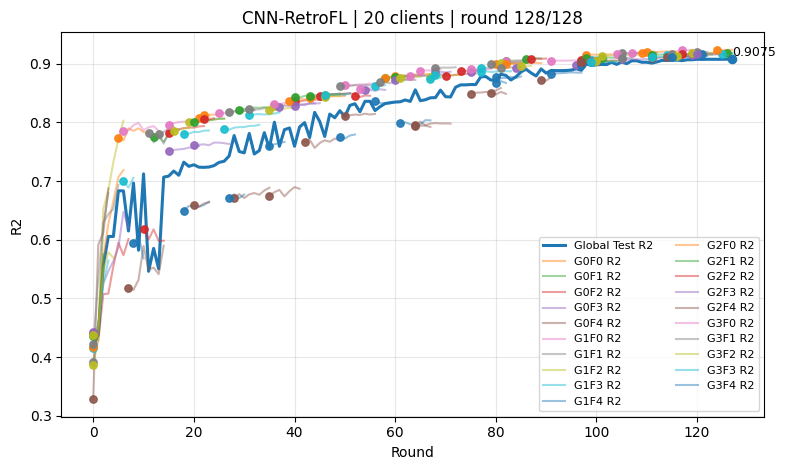

RetroFL-CNN-20c: 100%|██████████| 128/128 [3:57:50<00:00, 111.49s/it, online=3, last_client=['G2F0', 'G0F1', 'G1F3'], last_train_r2=[0.9235, 0.9184, 0.9169], global_r2=0.9075, lr=1.00e-06]                                                                                                                                  


[DONE] CNN-20c | final_r2=0.9075 | tail_std=0.0028 | time=14270.6s


{'arch': 'CNN',
 'n_clients': 20,
 'final_r2': 0.907532119121326,
 'tail_std': 0.0028296813851239255,
 'n_params': 4677508,
 'total_rounds': 128,
 'train_circuits': 57000,
 'test_circuits': 3000,
 'wall_clock_seconds': 14270.639808654785}

In [9]:
# ============================================================
# run
# ============================================================
pack = load_rf_pack(MATRIX_DIR, TARGET_DIR, TARGET_MODE)

# 可改成 3 / 5 / 10 / 20
result = run_one_experiment(
    pack=pack,
    n_clients=20,
    total_rounds=TOTAL_ROUNDS,
)

result